<a href="https://colab.research.google.com/github/vshalisko/ARC_analysis_scripts/blob/master/San%20Gabriel/SGB_2020_construir_numpy_8capas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Sierra de San Gabriel 2020
### Construcción del arrays NumPy de 8 capas por sensor + RobustScaler/Standard Scaler + PCA

Pasos:
1. Leer los GeoTIFF de 4 bandas (`NDVI, TC_Brightness, TC_Greenness, TC_Wetness`).
2. Construir el array `(4 bandas, alto, ancho)` por temporada.
3. Combinar las temporadas de seca y húmeda en un solo array, esto ya sería las`(8 bandas, alto, ancho)` por sensor.
4. Aplicar el método `RobustScaler` (no acepta valores NaN), entonces se filtraron los pixeles para que no falle o contamine la mediana/IQR.Para eso se usa el método `mask_valida.`
5. Aplicar el método `StandardScaler` (no acepta valores NaN), entonces se filtraron los pixeles para que no falle o contamine la promedio/SD.Para eso se usa el método `mask_valida.`
6. Guardar el array escalado (`.npy`) y el orden de capas (`.json`) por sensor.
7. Realizar PCA en cada conjunto
8. Guardar los resultados de PCA en NumPy array

Notas: versión preliminar, falta optimizar para reducir la redundancia del código


In [1]:
# Prefijo del área
PREFIJO     = 'SGB'
# Nombre del área
NOMBRE      = 'San_Gabriel'

# Ruta de la carpeta de Drive donde estan los .tif exportados
#RUTA_TIF = '/content/drive/MyDrive/ANP/Landsat/SVerde_Landsat/SVD_tif-2000'
RUTA_TIF = '/content/drive/MyDrive/Colab Data NDC 2020'

AÑO        = 2020

SENSORES   = ['L7', 'L8']
TEMPORADAS = ['seca', 'humeda']
NOMBRES_BANDAS = ['NDVI', 'TC_Brightness', 'TC_Greenness', 'TC_Wetness']

# Carpeta local donde se guardaran los .npy y .json de salida
#RUTA_SALIDA ='/content/drive/MyDrive/ANP/Landsat/SVerde_Landsat/SVD_tif-2000/Nympy2000'
RUTA_SALIDA = '/content/drive/MyDrive/Colab Data NDC 2020/Numpy'

In [2]:
import os
import glob
import json
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, StandardScaler
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
def buscar_tif(patron, avisar_si_hay_varios=True):     # si hay mas de uno agarramos el mas nuevo, pero igual avisamos
    candidatos = glob.glob(patron)
    if len(candidatos) == 0:
        raise FileNotFoundError(f"No se encontro tif con patron: {patron}")

    if len(candidatos) > 1:
        candidatos.sort(key=os.path.getmtime, reverse=True)
        if avisar_si_hay_varios:
            print(f"  Aviso: {len(candidatos)} archivos coinciden, usando el mas reciente: {os.path.basename(candidatos[0])}")

    return candidatos[0]


def encontrar_tif(prefijo, año, sensor, temporada, carpeta):
    patron = os.path.join(carpeta, f"{prefijo}_{año}_{sensor}_{temporada}.tif")
    candidatos = [f for f in glob.glob(patron) if 'bandas_corr' not in f]      #descarto los de bandas_corr
    if not candidatos:
        raise FileNotFoundError(f"No se encontro tif para {sensor} {temporada} con patron: {patron}")
    if len(candidatos) > 1:
        candidatos.sort(key=os.path.getmtime, reverse=True)
        print(f"  Aviso: {len(candidatos)} archivos coinciden para {sensor}-{temporada}, usando el mas reciente")
    return candidatos[0]


def leer_tif_a_array(path):       # devuelve (bandas, H, W) en float32 + el profile por si hace falta despues
    with rasterio.open(path) as src:
        arr = src.read().astype('float32')
        if src.nodata is not None and not np.isnan(src.nodata):
            arr[arr == src.nodata] = np.nan
        perfil = src.profile
    return arr, perfil


def construir_array_8capas(sensor, prefijo, año, carpeta, temporadas=TEMPORADAS, nombres_bandas=NOMBRES_BANDAS):
    partes = []
    orden_capas = []
    perfil_ref = None

    for temporada in temporadas:
        path = encontrar_tif(prefijo, año, sensor, temporada, carpeta)
        arr, perfil = leer_tif_a_array(path)

        if perfil_ref is None:
            perfil_ref = perfil
        else:  # las dos temporadas tienen que tener el mismo shape, sino algo se exporto mal en Earth Engine
            dim_ref = (perfil_ref['height'], perfil_ref['width'])
            if arr.shape[1:] != dim_ref:
                raise ValueError(f"Dimensiones de {sensor}-{temporada} {arr.shape[1:]} no coinciden con {dim_ref}")

        partes.append(arr)
        for b in nombres_bandas:
            orden_capas.append(f"{b}_{temporada}")

    array_8 = np.concatenate(partes, axis=0)
    return array_8, orden_capas, perfil_ref


def aplicar_robust_scaler(array_8capas):
    n_bandas, H, W = array_8capas.shape
    X = array_8capas.reshape(n_bandas, H * W).T          # (n_pixeles, 8)
    mask_valida = ~np.isnan(X).any(axis=1)

    if mask_valida.sum() == 0:
        raise ValueError("Todos los pixeles son NaN; no hay datos validos para escalar.")

    scaler = RobustScaler()
    X_escalado = np.full_like(X, np.nan)
    X_escalado[mask_valida] = scaler.fit_transform(X[mask_valida])

    array_escalado = X_escalado.T.reshape(n_bandas, H, W)
    return array_escalado, scaler

def aplicar_standard_scaler(array_8capas):
    n_bandas, H, W = array_8capas.shape
    X = array_8capas.reshape(n_bandas, H * W).T          # (n_pixeles, 8)
    mask_valida = ~np.isnan(X).any(axis=1)

    if mask_valida.sum() == 0:
        raise ValueError("Todos los pixeles son NaN; no hay datos validos para escalar.")

    scaler = StandardScaler()
    X_escalado = np.full_like(X, np.nan)
    X_escalado[mask_valida] = scaler.fit_transform(X[mask_valida])

    array_escalado = X_escalado.T.reshape(n_bandas, H, W)
    return array_escalado, scaler



## Ejecutar RobustScaler y StandardScaler para cada sensor

In [4]:
os.makedirs(RUTA_SALIDA, exist_ok=True)

resultados_rs = {}
resultados_ss = {}

for sensor in SENSORES:
    print(f"\nProcesando sensor {sensor}...")
    array_8, orden_capas, perfil = construir_array_8capas(sensor, PREFIJO, AÑO, RUTA_TIF)
    print(f"  Array combinado (seca+humeda): shape = {array_8.shape}")

    array_escalado_rs, scaler_rs = aplicar_robust_scaler(array_8)
    array_escalado_ss, scaler_ss = aplicar_standard_scaler(array_8)
    print(f"  Array escalado (RS): shape = {array_escalado_rs.shape}, "
          f"NaN preservados = {np.isnan(array_escalado_rs).sum()}")
    print(f"  Array escalado (SS): shape = {array_escalado_ss.shape}, "
          f"NaN preservados = {np.isnan(array_escalado_ss).sum()}")

    resultados_rs[sensor] = {
        'array': array_escalado_rs,
        'orden_capas': orden_capas,
        'perfil': perfil,
        'scaler': scaler_rs,
    }

    resultados_ss[sensor] = {
        'array': array_escalado_ss,
        'orden_capas': orden_capas,
        'perfil': perfil,
        'scaler': scaler_ss,
    }

    ruta_npy_rs  = os.path.join(RUTA_SALIDA, f'{PREFIJO}_{AÑO}_{sensor}_8capas_escalado_rs.npy')
    ruta_npy_ss  = os.path.join(RUTA_SALIDA, f'{PREFIJO}_{AÑO}_{sensor}_8capas_escalado_ss.npy')
    ruta_json = os.path.join(RUTA_SALIDA, f'{PREFIJO}_{AÑO}_{sensor}_8capas_orden.json')

    np.save(ruta_npy_rs, array_escalado_rs)
    np.save(ruta_npy_ss, array_escalado_ss)

    with open(ruta_json, 'w') as f:
        json.dump(orden_capas, f, ensure_ascii=False, indent=2)

    print(f"  Guardado: {ruta_npy_rs}")
    print(f"  Guardado: {ruta_npy_ss}")
    print(f"  Guardado: {ruta_json}")

print("\nOrden de capas (igual para todos los sensores y tipos de transformación):")
print(resultados_rs[SENSORES[0]]['orden_capas'])



Procesando sensor L7...
  Array combinado (seca+humeda): shape = (8, 464, 486)
  Array escalado (RS): shape = (8, 464, 486), NaN preservados = 16224
  Array escalado (SS): shape = (8, 464, 486), NaN preservados = 16224
  Guardado: /content/drive/MyDrive/Colab Data NDC 2020/Numpy/SGB_2020_L7_8capas_escalado_rs.npy
  Guardado: /content/drive/MyDrive/Colab Data NDC 2020/Numpy/SGB_2020_L7_8capas_escalado_ss.npy
  Guardado: /content/drive/MyDrive/Colab Data NDC 2020/Numpy/SGB_2020_L7_8capas_orden.json

Procesando sensor L8...
  Array combinado (seca+humeda): shape = (8, 464, 486)
  Array escalado (RS): shape = (8, 464, 486), NaN preservados = 16224
  Array escalado (SS): shape = (8, 464, 486), NaN preservados = 16224
  Guardado: /content/drive/MyDrive/Colab Data NDC 2020/Numpy/SGB_2020_L8_8capas_escalado_rs.npy
  Guardado: /content/drive/MyDrive/Colab Data NDC 2020/Numpy/SGB_2020_L8_8capas_escalado_ss.npy
  Guardado: /content/drive/MyDrive/Colab Data NDC 2020/Numpy/SGB_2020_L8_8capas_orden

## Verificación rápida (Robust Scaler)
Estadísticas básicas del array escalado para confirmar que RobustScaler funcionó como se espera (mediana ≈ 0, IQR ≈ 1 por capa, ignorando NaN).

Robust Scaler
L7
----------------------------------------
NDVI_seca: promedio=-0.1002  mediana=0.0000  SD=0.6714 IQR=1.0000  min=-2.9377  max=1.3654
TC_Brightness_seca: promedio=0.1469  mediana=0.0000  SD=0.8729 IQR=1.0000  min=-4.4849  max=21.1054
TC_Greenness_seca: promedio=-0.0379  mediana=-0.0000  SD=0.7005 IQR=1.0000  min=-2.9063  max=11.1942
TC_Wetness_seca: promedio=-0.1117  mediana=0.0000  SD=0.7300 IQR=1.0000  min=-8.9230  max=2.2168
NDVI_humeda: promedio=-0.2521  mediana=0.0000  SD=0.9870 IQR=1.0000  min=-8.9704  max=3.0788
TC_Brightness_humeda: promedio=0.1413  mediana=-0.0000  SD=0.9136 IQR=1.0000  min=-3.6756  max=16.2333
TC_Greenness_humeda: promedio=0.0545  mediana=0.0000  SD=0.9761 IQR=1.0000  min=-5.2396  max=15.4974
TC_Wetness_humeda: promedio=-0.1286  mediana=0.0000  SD=0.8771 IQR=1.0000  min=-12.8679  max=2.8916
Robust Scaler
L8
----------------------------------------
NDVI_seca: promedio=-0.0885  mediana=0.0000  SD=0.6445 IQR=1.0000  min=-3.6842  max=1.2397
TC_Brig

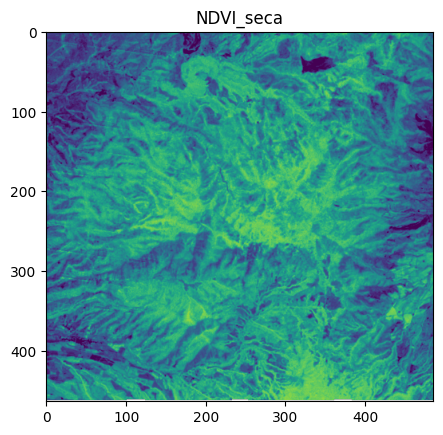

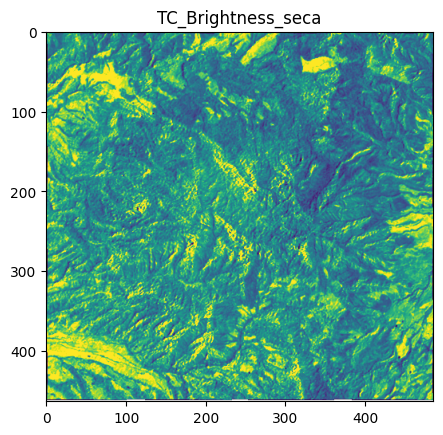


L8
----------------------------------------


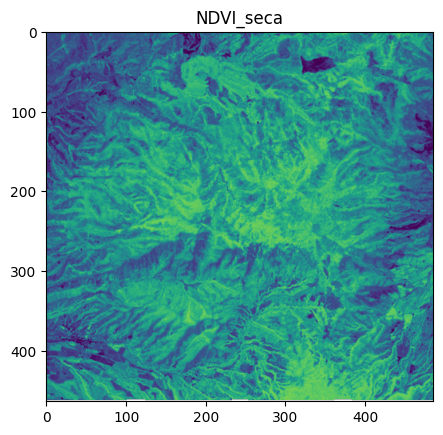

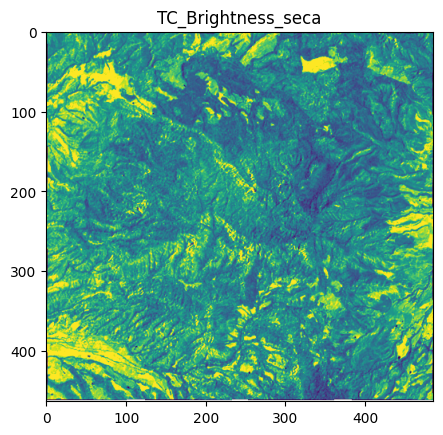

In [5]:
for sensor in SENSORES:
    arr = resultados_rs[sensor]['array']
    orden = resultados_rs[sensor]['orden_capas']
    print(f"Robust Scaler\n{sensor}")
    print("-" * 40)

    for i in range(len(orden)):
        nombre = orden[i]
        capa = arr[i]
        valida = capa[~np.isnan(capa)]
        mediana = np.median(valida)
        promedio = np.mean(valida)
        sd = np.std(valida)
        q1 = np.percentile(valida, 25)
        q3 = np.percentile(valida, 75)
        print(f"{nombre}: promedio={promedio:.4f}  mediana={mediana:.4f}  SD={sd:.4f} IQR={q3 - q1:.4f}  min={valida.min():.4f}  max={valida.max():.4f}")

for sensor in SENSORES:
    arr = resultados_rs[sensor]['array']
    orden = resultados_rs[sensor]['orden_capas']
    print(f"\n{sensor}")
    print("-" * 40)

    plt.imshow(arr[0,:,:], vmin=-2, vmax=2)
    plt.title(orden[0])
    plt.show()

    plt.imshow(arr[1,:,:], vmin=-2, vmax=2)
    plt.title(orden[1])
    plt.show()



## Verificación rápida (Standard Scaler)
Estadísticas básicas del array escalado para confirmar que StandardScaler funcionó como se espera (primedio ≈ 0, SD ≈ 1 por capa, ignorando NaN).

Standard Scaler
L7
----------------------------------------
NDVI_seca: promedio=-0.0000  mediana=0.1493  SD=1.0000 IQR=1.4895  min=-4.2265  max=2.1831
TC_Brightness_seca: promedio=0.0000  mediana=-0.1683  SD=1.0000 IQR=1.1456  min=-5.3063  max=24.0105
TC_Greenness_seca: promedio=0.0000  mediana=0.0541  SD=1.0000 IQR=1.4276  min=-4.0948  max=16.0344
TC_Wetness_seca: promedio=-0.0000  mediana=0.1531  SD=1.0000 IQR=1.3698  min=-12.0694  max=3.1895
NDVI_humeda: promedio=0.0000  mediana=0.2554  SD=1.0000 IQR=1.0132  min=-8.8335  max=3.3750
TC_Brightness_humeda: promedio=0.0000  mediana=-0.1547  SD=1.0000 IQR=1.0945  min=-4.1778  max=17.6133
TC_Greenness_humeda: promedio=0.0000  mediana=-0.0558  SD=1.0000 IQR=1.0245  min=-5.4236  max=15.8209
TC_Wetness_humeda: promedio=0.0000  mediana=0.1467  SD=1.0000 IQR=1.1401  min=-14.5242  max=3.4434
Standard Scaler
L8
----------------------------------------
NDVI_seca: promedio=0.0000  mediana=0.1373  SD=1.0000 IQR=1.5516  min=-5.5789  max=2.0608
TC_Br

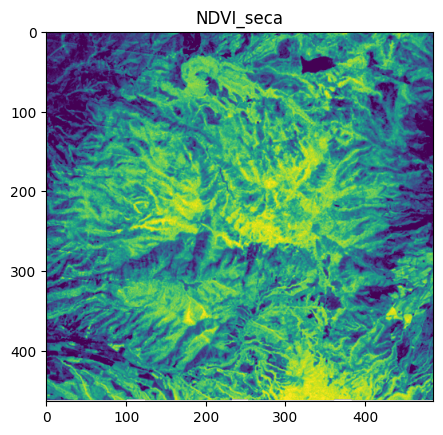

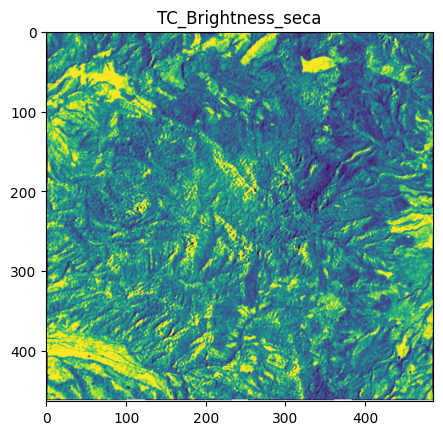


L8
----------------------------------------


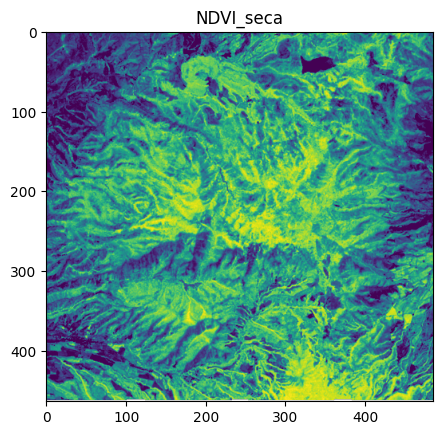

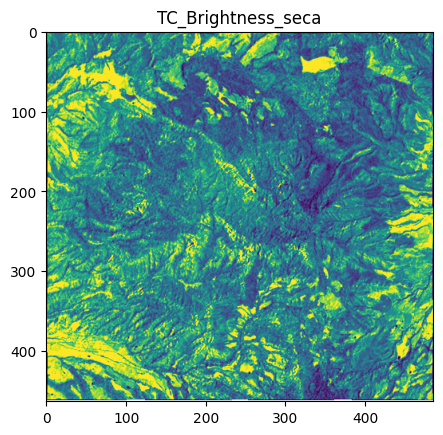

In [6]:
for sensor in SENSORES:
    arr = resultados_ss[sensor]['array']
    orden = resultados_ss[sensor]['orden_capas']
    print(f"Standard Scaler\n{sensor}")
    print("-" * 40)

    for i in range(len(orden)):
        nombre = orden[i]
        capa = arr[i]
        valida = capa[~np.isnan(capa)]
        mediana = np.median(valida)
        promedio = np.mean(valida)
        sd = np.std(valida)
        q1 = np.percentile(valida, 25)
        q3 = np.percentile(valida, 75)
        print(f"{nombre}: promedio={promedio:.4f}  mediana={mediana:.4f}  SD={sd:.4f} IQR={q3 - q1:.4f}  min={valida.min():.4f}  max={valida.max():.4f}")

for sensor in SENSORES:
    arr = resultados_ss[sensor]['array']
    orden = resultados_ss[sensor]['orden_capas']
    print(f"\n{sensor}")
    print("-" * 40)

    plt.imshow(arr[0,:,:], vmin=-2, vmax=2)
    plt.title(orden[0])
    plt.show()

    plt.imshow(arr[1,:,:], vmin=-2, vmax=2)
    plt.title(orden[1])
    plt.show()

# PCA con datos de RobustScaler

In [7]:
from sklearn.decomposition import PCA

# Initialize a dictionary to store PCA results
pca_resultados_rs = {}
pca_rs = PCA(n_components=6)

for sensor in ['L8','L7']:
    print(f"\nApplying PCA for sensor {sensor}...")
    # Get the scaled array for the current sensor
    array_escalado = resultados_rs[sensor]['array']
    n_bands, H, W = array_escalado.shape

    # Reshape the array from (bands, H, W) to (pixels, bands)
    # and handle NaN values for PCA
    X = array_escalado.reshape(n_bands, H * W).T  # (n_pixels, n_bands)

    # Create a mask to identify valid (non-NaN) pixels
    mask_valida = ~np.isnan(X).any(axis=1)

    if mask_valida.sum() == 0:
        print(f"  Warning: No valid pixels found for sensor {sensor}. Skipping PCA.")
        pca_resultados_rs[sensor] = {
            'transformed_array': np.full_like(X, np.nan).reshape(H, W, 6).transpose(2,0,1),
            'pca_model': None,
            'mask_valida': mask_valida
        }
        continue

    # Fit PCA only on valid data
    X_valid = X[mask_valida]

    # Train (fit) PCA with 6 components only for L8
    if sensor == 'L8':
        pca_rs.fit(X_valid)
        print(f"  Explained variance ratio: {pca_rs.explained_variance_ratio_.sum():.4f}")

    # Transform the valid data
    X_pca_valid = pca_rs.transform(X_valid)

    # Create an output array for PCA results, initialized with NaNs
    X_pca = np.full((H * W, 6), np.nan, dtype=np.float32)
    # Place the transformed valid data back into the correct positions
    X_pca[mask_valida] = X_pca_valid

    # Reshape the PCA result back to image dimensions (components, H, W)
    array_pca = X_pca.T.reshape(6, H, W)

    pca_resultados_rs[sensor] = {
        'transformed_array': array_pca,
        'pca_model': pca_rs,
        'mask_valida': mask_valida,
        'orden_capas': pca_rs.get_feature_names_out()
    }

    print(f"  PCA applied. Transformed array shape: {array_pca.shape}")

    ruta_npy_pca_rs  = os.path.join(RUTA_SALIDA, f'{PREFIJO}_{AÑO}_{sensor}_PCA6_rs.npy')
    ruta_npy_valid_rs  = os.path.join(RUTA_SALIDA, f'{PREFIJO}_{AÑO}_{sensor}_PCA6_rs_valid_mask.npy')
    np.save(ruta_npy_pca_rs, array_pca)
    print(f"  Guardado PCA RS: {ruta_npy_pca_rs}")
    np.save(ruta_npy_valid_rs, mask_valida)
    print(f"  Guardado mascara validos RS: {ruta_npy_valid_rs}")

    ## orden de capas PCA es el mismo para RS y SS, se guarda solo una vez
    ruta_json_orden_pca = os.path.join(RUTA_SALIDA, f'{PREFIJO}_{AÑO}_{sensor}_PCA6_orden.json')
    with open(ruta_json_orden_pca, 'w') as f:
        json.dump(pca_resultados_rs[sensor]['orden_capas'].tolist(), f, ensure_ascii=False, indent=2)



Applying PCA for sensor L8...
  Explained variance ratio: 0.9967
  PCA applied. Transformed array shape: (6, 464, 486)
  Guardado PCA RS: /content/drive/MyDrive/Colab Data NDC 2020/Numpy/SGB_2020_L8_PCA6_rs.npy
  Guardado mascara validos RS: /content/drive/MyDrive/Colab Data NDC 2020/Numpy/SGB_2020_L8_PCA6_rs_valid_mask.npy

Applying PCA for sensor L7...
  PCA applied. Transformed array shape: (6, 464, 486)
  Guardado PCA RS: /content/drive/MyDrive/Colab Data NDC 2020/Numpy/SGB_2020_L7_PCA6_rs.npy
  Guardado mascara validos RS: /content/drive/MyDrive/Colab Data NDC 2020/Numpy/SGB_2020_L7_PCA6_rs_valid_mask.npy


### Verificación rapida PCA RS


L7
----------------------------------------
pca0: promedio=0.1596  mediana=0.4194  SD=1.1767 IQR=1.2518  min=-9.5912  max=2.4430
pca1: promedio=-0.0282  mediana=0.1368  SD=1.0352 IQR=1.1063  min=-6.9078  max=7.4609
pca2: promedio=-0.1432  mediana=-0.0228  SD=0.8476 IQR=1.2562  min=-6.4713  max=2.8521
pca3: promedio=0.0343  mediana=-0.0141  SD=0.4856 IQR=0.5151  min=-6.1886  max=11.6122
pca4: promedio=0.0852  mediana=0.0206  SD=0.4664 IQR=0.6189  min=-2.4690  max=7.0673
pca5: promedio=0.0773  mediana=-0.0094  SD=0.5859 IQR=0.6794  min=-4.3004  max=14.2044

L8
----------------------------------------
pca0: promedio=0.0000  mediana=0.2614  SD=1.6561 IQR=1.9244  min=-26.6664  max=5.9750
pca1: promedio=0.0000  mediana=0.0051  SD=1.1520 IQR=1.2881  min=-8.8052  max=25.3842
pca2: promedio=-0.0000  mediana=0.0245  SD=0.9059 IQR=1.1713  min=-2.9113  max=15.0609
pca3: promedio=0.0000  mediana=0.0178  SD=0.5022 IQR=0.5249  min=-12.7954  max=10.4501
pca4: promedio=0.0000  mediana=0.0004  SD=0.436

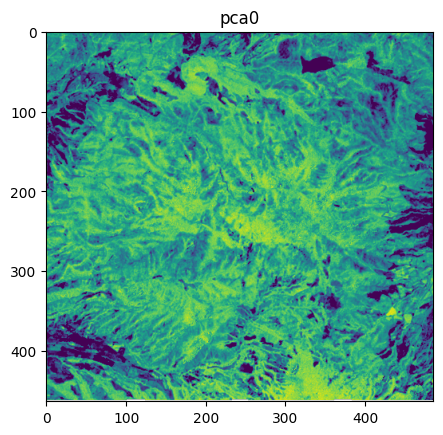

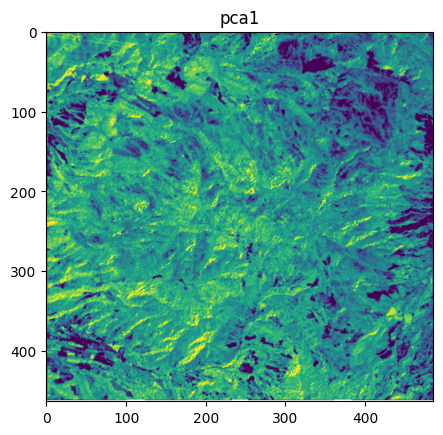

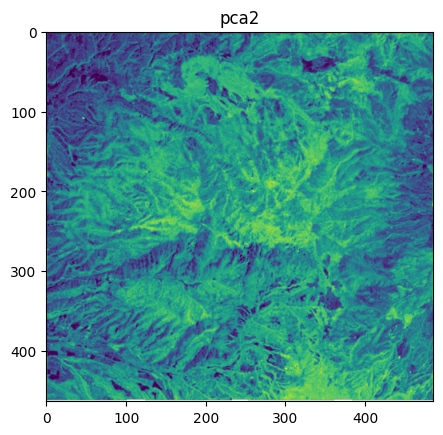


L8
----------------------------------------


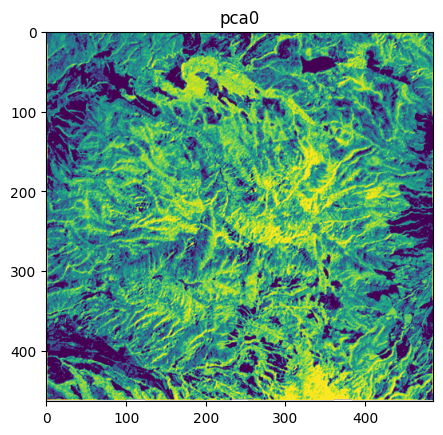

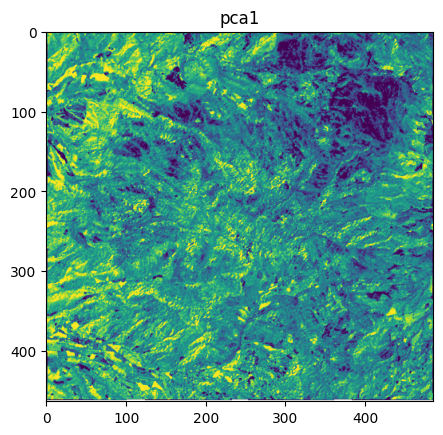

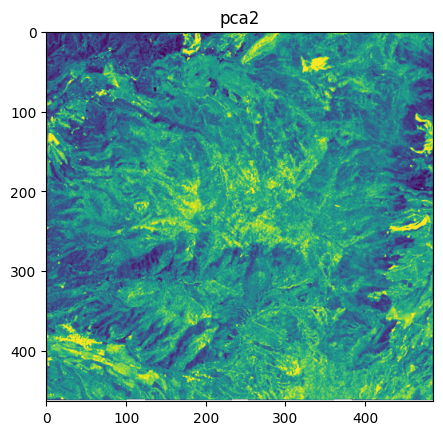

In [8]:
for sensor in SENSORES:
    arr = pca_resultados_rs[sensor]['transformed_array']
    orden = pca_resultados_rs[sensor]['orden_capas']
    print(f"\n{sensor}")
    print("-" * 40)

    for i in range(len(orden)):
        nombre = orden[i]
        capa = arr[i]
        valida = capa[~np.isnan(capa)]
        mediana = np.median(valida)
        promedio = np.mean(valida)
        sd = np.std(valida)
        q1 = np.percentile(valida, 25)
        q3 = np.percentile(valida, 75)
        print(f"{nombre}: promedio={promedio:.4f}  mediana={mediana:.4f}  SD={sd:.4f} IQR={q3 - q1:.4f}  min={valida.min():.4f}  max={valida.max():.4f}")


for sensor in SENSORES:
    arr = pca_resultados_rs[sensor]['transformed_array']
    orden = pca_resultados_rs[sensor]['orden_capas']
    print(f"\n{sensor}")
    print("-" * 40)

    plt.imshow(arr[0,:,:], vmin=-2.5, vmax=2.5)
    plt.title(orden[0])
    plt.show()

    plt.imshow(arr[1,:,:], vmin=-2.5, vmax=2.5)
    plt.title(orden[1])
    plt.show()

    plt.imshow(arr[2,:,:], vmin=-2.5, vmax=2.5)
    plt.title(orden[2])
    plt.show()

# PCA con datos de StandardScaler

In [9]:
# Initialize a dictionary to store PCA results
pca_resultados_ss = {}
pca_ss = PCA(n_components=6)

for sensor in ['L8','L7']:
    print(f"\nApplying PCA for sensor {sensor}...")
    # Get the scaled array for the current sensor
    array_escalado = resultados_ss[sensor]['array']
    n_bands, H, W = array_escalado.shape

    # Reshape the array from (bands, H, W) to (pixels, bands)
    # and handle NaN values for PCA
    X = array_escalado.reshape(n_bands, H * W).T  # (n_pixels, n_bands)

    # Create a mask to identify valid (non-NaN) pixels
    mask_valida = ~np.isnan(X).any(axis=1)

    if mask_valida.sum() == 0:
        print(f"  Warning: No valid pixels found for sensor {sensor}. Skipping PCA.")
        pca_resultados_ss[sensor] = {
            'transformed_array': np.full_like(X, np.nan).reshape(H, W, 6).transpose(2,0,1),
            'pca_model': None,
            'mask_valida': mask_valida
        }
        continue

    # Fit PCA only on valid data
    X_valid = X[mask_valida]

    # Train (fit) PCA with 6 components only for L8
    if sensor == 'L8':
        pca_ss.fit(X_valid)
        print(f"  Explained variance ratio: {pca_ss.explained_variance_ratio_.sum():.4f}")

    # Transform the valid data
    X_pca_valid = pca_ss.transform(X_valid)

    # Create an output array for PCA results, initialized with NaNs
    X_pca = np.full((H * W, 6), np.nan, dtype=np.float32)
    # Place the transformed valid data back into the correct positions
    X_pca[mask_valida] = X_pca_valid

    # Reshape the PCA result back to image dimensions (components, H, W)
    array_pca = X_pca.T.reshape(6, H, W)

    pca_resultados_ss[sensor] = {
        'transformed_array': array_pca,
        'pca_model': pca_ss,
        'mask_valida': mask_valida,
        'orden_capas': pca_ss.get_feature_names_out()
    }

    print(f"  PCA applied. Transformed array shape: {array_pca.shape}")

    ruta_npy_pca_ss  = os.path.join(RUTA_SALIDA, f'{PREFIJO}_{AÑO}_{sensor}_PCA6_ss.npy')
    ruta_npy_valid_ss  = os.path.join(RUTA_SALIDA, f'{PREFIJO}_{AÑO}_{sensor}_PCA6_ss_valid_mask.npy')
    np.save(ruta_npy_pca_ss, array_pca)
    print(f"  Guardado PCA SS: {ruta_npy_pca_ss}")
    np.save(ruta_npy_valid_ss, mask_valida)
    print(f"  Guardado mascara validos SS: {ruta_npy_valid_ss}")



Applying PCA for sensor L8...
  Explained variance ratio: 0.9962
  PCA applied. Transformed array shape: (6, 464, 486)
  Guardado PCA SS: /content/drive/MyDrive/Colab Data NDC 2020/Numpy/SGB_2020_L8_PCA6_ss.npy
  Guardado mascara validos SS: /content/drive/MyDrive/Colab Data NDC 2020/Numpy/SGB_2020_L8_PCA6_ss_valid_mask.npy

Applying PCA for sensor L7...
  PCA applied. Transformed array shape: (6, 464, 486)
  Guardado PCA SS: /content/drive/MyDrive/Colab Data NDC 2020/Numpy/SGB_2020_L7_PCA6_ss.npy
  Guardado mascara validos SS: /content/drive/MyDrive/Colab Data NDC 2020/Numpy/SGB_2020_L7_PCA6_ss_valid_mask.npy


### Verificaciín rapida PCA SS


L7
----------------------------------------
pca0: promedio=0.0000  mediana=0.2512  SD=1.3847 IQR=1.6966  min=-10.2553  max=2.7945
pca1: promedio=0.0000  mediana=0.1873  SD=1.3596 IQR=1.6664  min=-7.5802  max=7.9589
pca2: promedio=0.0000  mediana=0.1752  SD=0.9336 IQR=1.2028  min=-8.3921  max=5.3791
pca3: promedio=0.0000  mediana=-0.0157  SD=0.5293 IQR=0.5948  min=-6.2588  max=10.6333
pca4: promedio=0.0000  mediana=-0.0619  SD=0.6237 IQR=0.7427  min=-5.4746  max=13.2009
pca5: promedio=-0.0000  mediana=-0.0861  SD=0.5386 IQR=0.5848  min=-4.1628  max=11.3155

L8
----------------------------------------
pca0: promedio=0.0000  mediana=0.2606  SD=2.0439 IQR=2.6911  min=-36.2832  max=7.5842
pca1: promedio=0.0000  mediana=0.0051  SD=1.3183 IQR=1.5046  min=-7.7145  max=27.2957
pca2: promedio=0.0000  mediana=0.0847  SD=1.1562 IQR=1.3424  min=-3.9229  max=16.5797
pca3: promedio=0.0000  mediana=0.0038  SD=0.5986 IQR=0.5883  min=-10.9863  max=11.3691
pca4: promedio=0.0000  mediana=-0.0027  SD=0.53

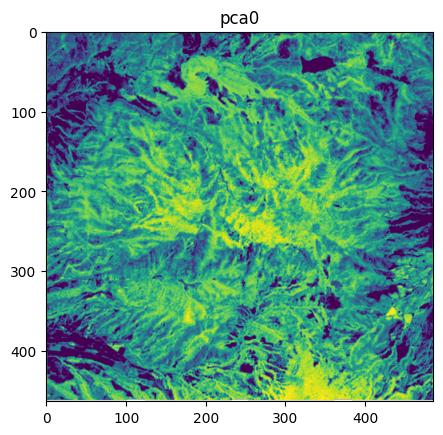

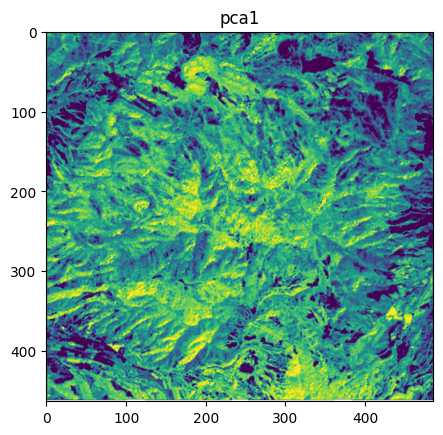

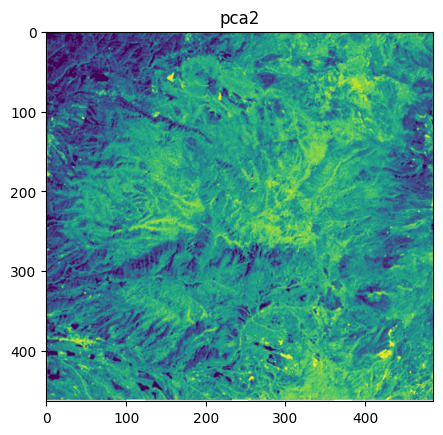


L8
----------------------------------------


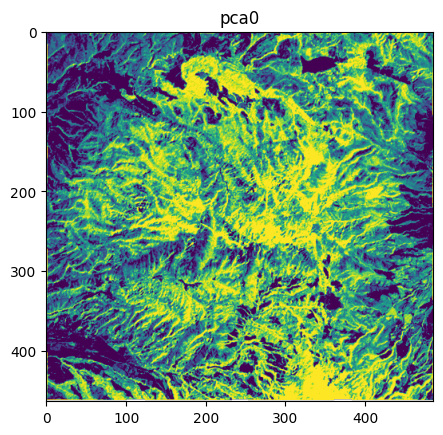

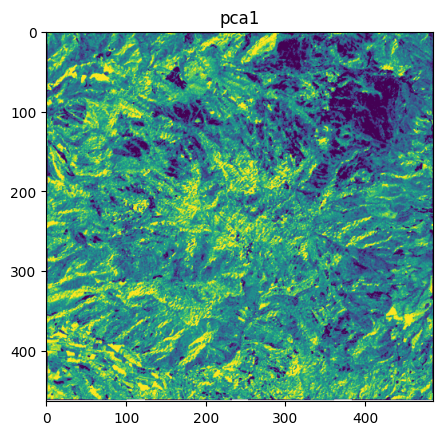

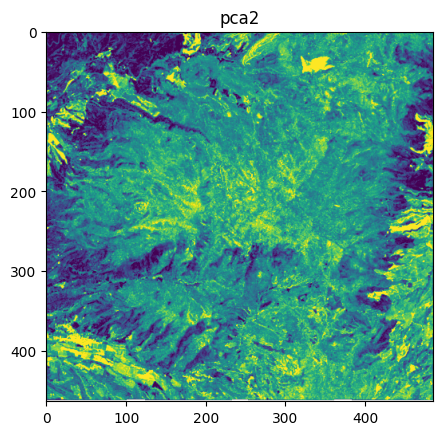

In [10]:
for sensor in SENSORES:
    arr = pca_resultados_ss[sensor]['transformed_array']
    orden = pca_resultados_ss[sensor]['orden_capas']
    print(f"\n{sensor}")
    print("-" * 40)

    for i in range(len(orden)):
        nombre = orden[i]
        capa = arr[i]
        valida = capa[~np.isnan(capa)]
        mediana = np.median(valida)
        promedio = np.mean(valida)
        sd = np.std(valida)
        q1 = np.percentile(valida, 25)
        q3 = np.percentile(valida, 75)
        print(f"{nombre}: promedio={promedio:.4f}  mediana={mediana:.4f}  SD={sd:.4f} IQR={q3 - q1:.4f}  min={valida.min():.4f}  max={valida.max():.4f}")


for sensor in SENSORES:
    arr = pca_resultados_ss[sensor]['transformed_array']
    orden = pca_resultados_ss[sensor]['orden_capas']
    print(f"\n{sensor}")
    print("-" * 40)

    plt.imshow(arr[0,:,:], vmin=-2.5, vmax=2.5)
    plt.title(orden[0])
    plt.show()

    plt.imshow(arr[1,:,:], vmin=-2.5, vmax=2.5)
    plt.title(orden[1])
    plt.show()

    plt.imshow(arr[2,:,:], vmin=-2.5, vmax=2.5)
    plt.title(orden[2])
    plt.show()